# Drone-versus-bird radar classification baseline

This notebook audits an extracted `Data` directory, converts each recording into a documented micro-Doppler representation, trains a leakage-checked logistic classifier, evaluates it on held-out recording groups, and exports a reproducible model bundle. Its archive contract is grounded in Kang *et al.*, “Millimeter Wave Radar Measurements: Distinguishing UAS and Birds Based on 60 GHz micro-Doppler Signatures” (VTC2024-Fall, DOI `10.1109/VTC2024-Fall63153.2024.10757735`). The separate live-IWR6843 contract is read from `rawdatacapture/profile.cfg`.

**Scope:** the archive contains DJI Mavic and Phantom 3 Pro drones, bionic birds, and one pole recording. Consequently, this is an **archive drone-vs-bionic-bird baseline**, not a validated general drone detector. The pole is excluded from binary training and retained as an unknown robustness probe. Deployment requires held-out IWR6843ISK-ODS recordings.

**Corrected archive interpretation:** each pickle is a time sequence of already processed complex 2D radar images—not a raw chirp/ADC cube. The paper describes a custom 60 GHz, 6 GHz-bandwidth, 8-TX/8-RX FDM-FMCW MIMO radar, 1 kHz pulse-repetition frequency, one-second anechoic-chamber measurements at 2.5 m, and phase-based micro-Doppler analysis over time. Each notebook example remains `micro_doppler[2, 48, 64]`, but its channels are now amplitude-weighted complex and phase-angle temporal STFT power from a 20×30 spatial target crop. At 1 kHz, one example spans 440 ms.

**Modeling distinction:** this notebook remains its own compact baseline, not a reproduction of the paper's networks. The paper feeds one 20×30 amplitude image to a residual CNN and consecutive 20×30 phase frames to a ConvLSTM; the notebook instead converts both signals to temporal-frequency maps for its logistic and compact-CNN baselines.

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from __future__ import annotations

import ctypes
import gc
import hashlib
import io
import json
import os
import pickle
import platform
import re
import shutil
import sys
import time
import warnings
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy import fft as sp_fft
from sklearn import __version__ as sklearn_version
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, brier_score_loss,
    confusion_matrix, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold

RANDOM_STATE = 42
WINDOW_STEPS = 48
DOPPLER_BINS = 64
WINDOW_STRIDE = 24  # overlap is allowed only within a recording group
ARCHIVE_SAMPLE_RATE_HZ = 1_000.0
ARCHIVE_STFT_WINDOW_SAMPLES = 64
ARCHIVE_STFT_HOP_SAMPLES = 8
ARCHIVE_ROI_AXIS0_BINS = 20
ARCHIVE_ROI_AXIS1_BINS = 30
FEATURE_VERSION = "paper-phase-micro-doppler-v5"
PIPELINE_REVISION = "paper-corrected-neutral-spatial-phase-stft-r9"
MAX_RECORDINGS = None  # set an integer only for a quick smoke test
CACHE_FEATURES = True
DRIVE_DOWNLOAD_WORKERS = 8
DRIVE_STREAM_CHUNK_MIB = 8
DRIVE_DOWNLOAD_RETRIES = 5

def detect_available_cpu_cores() -> int:
    # os.cpu_count() can expose host CPUs that a Colab container cannot use.
    try:
        affinity_cores = len(os.sched_getaffinity(0))
    except (AttributeError, OSError):
        affinity_cores = os.cpu_count() or 1

    quota_cores = None
    try:
        quota, period = Path("/sys/fs/cgroup/cpu.max").read_text().strip().split()
        if quota != "max":
            quota_cores = max(1, int(quota) // int(period))
    except (OSError, ValueError):
        try:
            quota = int(Path("/sys/fs/cgroup/cpu/cpu.cfs_quota_us").read_text())
            period = int(Path("/sys/fs/cgroup/cpu/cpu.cfs_period_us").read_text())
            if quota > 0:
                quota_cores = max(1, quota // period)
        except (OSError, ValueError):
            pass

    return max(1, min(affinity_cores, quota_cores) if quota_cores else affinity_cores)

AVAILABLE_CPU_CORES = detect_available_cpu_cores()
FEATURE_EXTRACTION_WORKERS = AVAILABLE_CPU_CORES

IS_COLAB = "google.colab" in sys.modules
DRIVE_API = None
DRIVE_CREDENTIALS = None
if IS_COLAB:
    from google.colab import auth, drive
    from google.auth import default as google_auth_default
    from google.auth.exceptions import TransportError
    from google.auth.transport.requests import AuthorizedSession
    from googleapiclient.discovery import build
    from requests import RequestException
    drive_root = Path("/content/drive/MyDrive")
    try:
        drive_is_healthy = drive_root.is_dir() and next(drive_root.iterdir(), None) is not None
    except OSError:
        drive_is_healthy = False
    if not drive_is_healthy:
        print("Google Drive mount is unavailable or stale; remounting it.")
        drive.mount("/content/drive", force_remount=True)
    auth.authenticate_user()
    DRIVE_CREDENTIALS, _ = google_auth_default()
    DRIVE_API = build("drive", "v3", credentials=DRIVE_CREDENTIALS, cache_discovery=False)

configured_repo = os.environ.get("RADAR_UREX_REPO")
repo_candidates = ([Path(configured_repo)] if configured_repo else []) + [
    Path.cwd(), Path("/content/Radar-UREx"), Path("/content/drive/MyDrive/UREX/Radar-UREx")
]
REPO = next((path for path in repo_candidates if (path / "AI_2.md").exists()), None)
if REPO is None:
    raise RuntimeError("Radar-UREx repository not found. Set RADAR_UREX_REPO or run from its root.")
REPO = REPO.resolve()
os.chdir(REPO)

configured_source = os.environ.get("RADAR_UREX_DATA_SOURCE")
default_source = Path("/content/drive/MyDrive/Data") if IS_COLAB else Path(r"C:\Users\eliwe\Desktop\UREX\Data")
DATA_SOURCE = Path(configured_source) if configured_source else default_source
OUTPUT_DIR = REPO / "Radar-UREx-output"
CACHE_PATH = OUTPUT_DIR / "classification_features_v5.npz"
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"

print({
    "python": platform.python_version(), "numpy": np.__version__,
    "scipy": scipy.__version__, "scikit_learn": sklearn_version,
    "pipeline_revision": PIPELINE_REVISION,
    "download_workers": DRIVE_DOWNLOAD_WORKERS,
    "stream_chunk_mib": DRIVE_STREAM_CHUNK_MIB,
    "logical_cpu_count": os.cpu_count(),
    "available_cpu_cores": AVAILABLE_CPU_CORES,
    "feature_extraction_workers": FEATURE_EXTRACTION_WORKERS,
    "data_source": str(DATA_SOURCE),
    "source_kind": "google_drive_api" if IS_COLAB else "directory",
    "output_directory": str(OUTPUT_DIR),
    "feature_cache": str(CACHE_PATH), "artifact_directory": str(ARTIFACT_DIR),
})
if not IS_COLAB:
    assert DATA_SOURCE.is_dir(), f"Extracted data directory not found: {DATA_SOURCE}"


{'python': '3.12.13', 'numpy': '2.0.2', 'scipy': '1.16.3', 'scikit_learn': '1.6.1', 'pipeline_revision': 'paper-corrected-neutral-spatial-phase-stft-r9', 'download_workers': 8, 'stream_chunk_mib': 8, 'logical_cpu_count': 2, 'available_cpu_cores': 2, 'feature_extraction_workers': 2, 'data_source': '/content/drive/MyDrive/Data', 'source_kind': 'google_drive_api', 'output_directory': '/content/drive/MyDrive/UREX/Radar-UREx/Radar-UREx-output', 'feature_cache': '/content/drive/MyDrive/UREX/Radar-UREx/Radar-UREx-output/classification_features_v5.npz', 'artifact_directory': '/content/drive/MyDrive/UREX/Radar-UREx/Radar-UREx-output/artifacts'}


## 1. Archive and live radar contracts

The paper and the repository describe two different sensors and data products. The archive uses VTT's custom 60 GHz FDM-FMCW MIMO radar; the pickle files contain processed complex angle–distance images sampled over time. The repository's live IWR6843 produces raw chirp/RX/ADC cubes. These contracts must not be mixed or treated as shape-compatible.

The paper specifies the archive carrier band, bandwidth, MIMO channel counts, pulse-repetition frequency, duration, test distance, and measurement environment. It does **not** provide the released image-grid calibration, serialized spatial-axis order, FMCW slope, ADC sampling contract, or STFT window/hop. Consequently, the notebook reports frequency in hertz from the known 1 kHz sampling rate but retains crop coordinates as neutral spatial-axis bin indices. Notebook-selected STFT settings are documented separately from paper-reported parameters.

In [5]:
from rawdatacapture.livedatacapture import RadarCaptureConfig

PAPER_PATH = REPO / "tmp" / "pdfs" / (
    "Millimeter_Wave_Radar_Measurements_Distinguishing_UAS_and_Birds_"
    "Based_on_60_GHz_micro-Doppler_Signatures.pdf"
)
paper_sha256 = hashlib.sha256(PAPER_PATH.read_bytes()).hexdigest() if PAPER_PATH.exists() else None
archive_radar_contract = {
    "source": "Kang et al., VTC2024-Fall, DOI 10.1109/VTC2024-Fall63153.2024.10757735",
    "dataset_doi": "10.21227/c8r5-6h79",
    "radar": "VTT custom frequency-division-multiplexed FMCW MIMO",
    "center_frequency_ghz": 60.0,
    "bandwidth_ghz": 6.0,
    "nominal_range_resolution_m": 299_792_458.0 / (2.0 * 6e9),
    "transmitters": 8,
    "receivers": 8,
    "pulse_repetition_frequency_hz": ARCHIVE_SAMPLE_RATE_HZ,
    "measurement_duration_s": 1.0,
    "target_distance_m": 2.5,
    "environment": "VTT anechoic chamber",
    "measurement_states": ["stationary", "rotating propellers or flapping wings"],
    "objects": ["DJI Mavic", "DJI Phantom 3 Professional", "bionic bird"],
    "flat_surface_azimuth_deg": [0.0, 22.5, 45.0, 67.5, 90.0, 112.5, 135.0, 167.5, 180.0],
    "flat_surface_elevation_deg": [0.0],
    "tripod_azimuth_deg": [0.0, 45.0, 90.0],
    "tripod_elevation_deg": [-45.0, 0.0, 45.0],
    "released_data_product": "processed complex 2D horizontal-angle/distance image sequence",
    "released_tensor_axis_order": ["time", "spatial_axis_0_bin", "spatial_axis_1_bin"],
    "paper_spatial_axes": ["horizontal_angle", "distance"],
    "serialized_spatial_axis_mapping": None,
    "spatial_bin_calibration": None,
    "paper_sha256": paper_sha256,
}

PROFILE_PATH = REPO / "rawdatacapture" / "profile.cfg"
profile = RadarCaptureConfig.from_file(PROFILE_PATH)
profile_sha256 = hashlib.sha256(PROFILE_PATH.read_bytes()).hexdigest()
frame_period_ms = None
for line in PROFILE_PATH.read_text(encoding="utf-8").splitlines():
    tokens = line.split()
    if tokens and tokens[0] == "frameCfg":
        frame_period_ms = float(tokens[5])

live_radar_contract = {
    "num_adc_samples": profile.num_adc_samples,
    "num_rx_channels": profile.num_rx_channels,
    "num_chirps_per_frame": profile.num_chirps_per_frame,
    "num_loops_doppler_bins": profile.num_loops,
    "num_tdm_transmitters": profile.num_chirps_per_loop,
    "tx_channel_masks": profile.tx_channel_masks,
    "frame_period_ms": frame_period_ms,
    "range_bin_spacing_m": profile.range_resolution_m,
    "bytes_per_frame": profile.bytes_per_frame,
    "profile_sha256": profile_sha256,
}
archive_feature_span_s = (
    ARCHIVE_STFT_WINDOW_SAMPLES
    + (WINDOW_STEPS - 1) * ARCHIVE_STFT_HOP_SAMPLES
) / ARCHIVE_SAMPLE_RATE_HZ
print("Paper-grounded archive contract:\n", json.dumps(archive_radar_contract, indent=2))
print("Separate live IWR6843 contract:\n", json.dumps(live_radar_contract, indent=2))

assert profile.num_rx_channels == 4
assert profile.num_chirps_per_loop == 3
assert profile.num_loops == 128
assert profile.num_adc_samples == 64
assert profile.lvds_lanes == 2 and profile.iq_swap and not profile.channel_interleave
assert profile.num_loops % DOPPLER_BINS == 0
print(f"Archive feature span at 1 kHz: {archive_feature_span_s:.3f} s")


Paper-grounded archive contract:
 {
  "source": "Kang et al., VTC2024-Fall, DOI 10.1109/VTC2024-Fall63153.2024.10757735",
  "dataset_doi": "10.21227/c8r5-6h79",
  "radar": "VTT custom frequency-division-multiplexed FMCW MIMO",
  "center_frequency_ghz": 60.0,
  "bandwidth_ghz": 6.0,
  "nominal_range_resolution_m": 0.024982704833333334,
  "transmitters": 8,
  "receivers": 8,
  "pulse_repetition_frequency_hz": 1000.0,
  "measurement_duration_s": 1.0,
  "target_distance_m": 2.5,
  "environment": "VTT anechoic chamber",
  "measurement_states": [
    "stationary",
    "rotating propellers or flapping wings"
  ],
  "objects": [
    "DJI Mavic",
    "DJI Phantom 3 Professional",
    "bionic bird"
  ],
  "flat_surface_azimuth_deg": [
    0.0,
    22.5,
    45.0,
    67.5,
    90.0,
    112.5,
    135.0,
    167.5,
    180.0
  ],
  "flat_surface_elevation_deg": [
    0.0
  ],
  "tripod_azimuth_deg": [
    0.0,
    45.0,
    90.0
  ],
  "tripod_elevation_deg": [
    -45.0,
    0.0,
    45.0
  ],


## 2. Dataset audit and leakage groups

The data source is the extracted Google Drive directory `/content/drive/MyDrive/Data`. Only real `.pkl` recordings are used; `__MACOSX` resource forks and `.DS_Store` are ignored. Repeated copies are collapsed by canonical recording filename and file size; conflicting sizes for the same name stop the run. Labels come from the documented objects: filename prefixes `mavik` and `p3p` are DJI drones, `bird` is the paper's bionic bird, and the extra `pole` recording is an unknown probe not described in the paper.

The paper's campaign consists of one-second, 1 kHz measurements in stationary and rotating/flapping states, at multiple azimuth/elevation orientations. Two files explicitly marked `3khz` are supplementary recordings outside that stated contract; they are excluded rather than silently mapped onto the 1 kHz frequency axis. A complete recording is never split across partitions. Filenames differing only by motion/power condition share an inferred session group because authoritative session IDs are unavailable. The source fingerprint is SHA-256 over the retained canonical filename-and-size manifest.

In [6]:
def label_metadata(member: str) -> dict:
    stem = Path(member).stem.lower()
    if stem.startswith("mavik"):
        label, target_model = "drone", "dji_mavic"
    elif stem.startswith("p3p"):
        label, target_model = "drone", "phantom_3_pro"
    elif stem.startswith("bird"):
        label, target_model = "bird", "bionic_bird"
    elif stem.startswith("pole"):
        label, target_model = "unknown", "pole"
    else:
        raise ValueError(f"Unrecognized recording name: {member}")
    group = re.sub(r"_(still|rotation)(?=_|$)", "", stem)
    group = re.sub(r"_(5pct|50pct|100pct)$", "", group)
    return {"recording_id": stem, "label": label, "target_model": target_model, "session_group": group}

def drive_children(parent_id: str):
    page_token = None
    while True:
        response = DRIVE_API.files().list(
            q=f"'{parent_id}' in parents and trashed = false",
            spaces="drive", pageSize=1000, pageToken=page_token,
            fields="nextPageToken, files(id,name,mimeType,size)",
        ).execute(num_retries=5)
        yield from response.get("files", [])
        page_token = response.get("nextPageToken")
        if not page_token:
            return

def drive_data_members() -> list[dict]:
    response = DRIVE_API.files().list(
        q="'root' in parents and name = 'Data' and "
          "mimeType = 'application/vnd.google-apps.folder' and trashed = false",
        spaces="drive", pageSize=100, fields="files(id,name)",
    ).execute(num_retries=5)
    roots = response.get("files", [])
    if len(roots) != 1:
        raise RuntimeError(f"Expected exactly one My Drive/Data folder; found {len(roots)}")
    found = []
    stack = [(roots[0]["id"], Path())]
    while stack:
        parent_id, relative_parent = stack.pop()
        for item in drive_children(parent_id):
            relative = relative_parent / item["name"]
            if item["mimeType"] == "application/vnd.google-apps.folder":
                stack.append((item["id"], relative))
            elif relative.suffix.lower() == ".pkl" and "__MACOSX" not in relative.parts and not relative.name.startswith("._"):
                found.append({"name": relative.as_posix(), "size": int(item["size"]),
                              "drive_file_id": item["id"]})
    return found

source_kind = "google_drive_api" if IS_COLAB else "directory"
if IS_COLAB:
    members = drive_data_members()
else:
    members = []
    for path in DATA_SOURCE.rglob("*.pkl"):
        relative = path.relative_to(DATA_SOURCE).as_posix()
        if "__MACOSX" in path.parts or path.name.startswith("._"):
            continue
        members.append({"name": relative, "size": path.stat().st_size})

unique_members = {}
duplicate_paths = []
for member in members:
    recording_name = Path(member["name"]).name.lower()
    existing = unique_members.get(recording_name)
    if existing is None:
        unique_members[recording_name] = member
        continue
    existing_signature = existing["size"]
    candidate_signature = member["size"]
    if candidate_signature != existing_signature:
        raise ValueError(
            f"Conflicting files share recording name {recording_name}: "
            f"{existing['name']} and {member['name']}"
        )
    # Retain the shallowest, then lexicographically first, identical copy.
    retained, skipped = sorted(
        [existing, member], key=lambda row: (len(Path(row["name"]).parts), row["name"].lower())
    )
    unique_members[recording_name] = retained
    duplicate_paths.append(skipped["name"])
members = list(unique_members.values())
members.sort(key=lambda item: item["name"])
excluded_nonpaper_members = [
    member for member in members if "3khz" in Path(member["name"]).stem.lower()
]
members = [member for member in members if member not in excluded_nonpaper_members]
if MAX_RECORDINGS is not None:
    # Smoke-test mode is deterministic and intentionally not used for final metrics.
    members = members[:int(MAX_RECORDINGS)]

central_manifest = [{"name": row["name"], "size": row["size"]} for row in members]
archive_fingerprint = hashlib.sha256(
    json.dumps(central_manifest, sort_keys=True, separators=(",", ":")).encode()
).hexdigest()
metadata = [label_metadata(member["name"]) | member for member in members]

from collections import Counter
print("recordings by model:", Counter(row["target_model"] for row in metadata))
print("recordings by class:", Counter(row["label"] for row in metadata))
print("duplicate filename/size copies skipped:", len(duplicate_paths))
print("non-paper 3 kHz recordings excluded:", [row["name"] for row in excluded_nonpaper_members])
print("source kind:", source_kind)
print("dataset GiB:", round(sum(member["size"] for member in members) / 2**30, 3))
print("dataset manifest fingerprint:", archive_fingerprint)
assert len(members) == 100 if MAX_RECORDINGS is None else True
assert Counter(row["target_model"] for row in metadata) == {
    "dji_mavic": 43, "phantom_3_pro": 18, "bionic_bird": 38, "pole": 1
} if MAX_RECORDINGS is None else True


recordings by model: Counter({'dji_mavic': 43, 'bionic_bird': 38, 'phantom_3_pro': 18, 'pole': 1})
recordings by class: Counter({'drone': 61, 'bird': 38, 'unknown': 1})
duplicate filename/size copies skipped: 102
non-paper 3 kHz recordings excluded: ['mavik_hover_3ft_3khz.pkl', 'mavik_hover_3ft_3khz_towards_radar.pkl']
source kind: google_drive_api
dataset GiB: 16.022
dataset manifest fingerprint: 7f3ddb0078b9b91547cd5dd805559f77c26da89e6e47a41ab88949bb8993244e


## 3. Safe loading and common feature representation

Pickle can execute arbitrary code. The restricted loader permits only the small set of NumPy reconstruction globals observed in this archive; do not replace it with unrestricted `pickle.load` for untrusted data. Every retained member must be a finite, 3-D `complex64` sequence. The paper identifies the two image dimensions as horizontal angle and distance, but neither the release nor the paper embeds their serialized NumPy order or calibrated coordinates. The notebook therefore uses the conservative tensor contract `[time sample, spatial axis 0 bin, spatial axis 1 bin]`. In Colab, each unique recording is copied locally before it is unpickled.

The paper first demodulates the FDM MIMO channels, assembles a linear virtual array, and performs an FFT to form each complex 2D radar image; that processing has already happened before these pickles. The notebook therefore performs no additional range or angle FFT. It locates the strongest time-mean spatial response without using the label, extracts the paper's 20×30 classifier-sized spatial region, and applies a temporal STFT across the known 1 kHz time axis. Channel 0 is the notebook's amplitude-weighted complex-STFT adaptation; channel 1 is STFT power of the phase angles in radians, matching the paper's definition of $x[n]$ as a discrete phase value. The paper does not report its STFT window/hop, so the notebook explicitly chooses a 64-sample Hann window, eight-sample hop, and 64-point FFT. This representation is paper-grounded but is not the paper's amplitude-CNN/phase-ConvLSTM input pipeline.

In [7]:
class RestrictedNumpyUnpickler(pickle.Unpickler):
    ALLOWED = {
        ("numpy._core.multiarray", "_reconstruct"),
        ("numpy.core.multiarray", "_reconstruct"),
        ("numpy", "ndarray"), ("numpy", "dtype"),
        ("numpy._core.multiarray", "scalar"),
        ("numpy.core.multiarray", "scalar"),
        ("_codecs", "encode"),
    }

    def find_class(self, module, name):
        if (module, name) not in self.ALLOWED:
            raise pickle.UnpicklingError(f"Blocked pickle global: {module}.{name}")
        return super().find_class(module, name)

_drive_thread_local = threading.local()

def drive_download_session():
    session = getattr(_drive_thread_local, "session", None)
    if session is None:
        session = AuthorizedSession(DRIVE_CREDENTIALS)
        session.headers.update({"Accept-Encoding": "identity"})
        _drive_thread_local.session = session
    return session

def stage_recording_locally(data_source: Path, member: str, expected_size: int,
                              drive_file_id: str | None = None) -> tuple[Path, str]:
    if not IS_COLAB:
        return data_source, member
    staging_root = Path("/content/radar_urex_staging")
    staging_root.mkdir(parents=True, exist_ok=True)
    staged_name = Path(member).name
    destination = staging_root / staged_name
    if destination.is_file() and destination.stat().st_size == expected_size:
        return staging_root, staged_name
    if not drive_file_id:
        raise ValueError(f"Missing Google Drive file ID for {member}")
    print(f"Downloading {member} through Drive API ({expected_size / 2**30:.2f} GiB)")
    temporary = destination.with_suffix(destination.suffix + ".part")
    url = f"https://www.googleapis.com/drive/v3/files/{drive_file_id}?alt=media"
    session = drive_download_session()
    last_error = None
    for attempt in range(DRIVE_DOWNLOAD_RETRIES + 1):
        offset = temporary.stat().st_size if temporary.exists() else 0
        if offset > expected_size:
            temporary.unlink()
            offset = 0
        headers = {"Range": f"bytes={offset}-"} if offset else {}
        try:
            with session.get(url, headers=headers, stream=True, timeout=(30, 300)) as response:
                if response.status_code == 416 and offset == expected_size:
                    break
                if offset and response.status_code == 200:
                    offset = 0  # Server ignored Range; safely restart this file.
                response.raise_for_status()
                mode = "ab" if offset and response.status_code == 206 else "wb"
                with temporary.open(mode) as destination_stream:
                    for chunk in response.iter_content(chunk_size=DRIVE_STREAM_CHUNK_MIB * 1024**2):
                        if chunk:
                            destination_stream.write(chunk)
                    destination_stream.flush()
                    os.fsync(destination_stream.fileno())
            if temporary.stat().st_size == expected_size:
                break
            raise OSError(f"Partial download: {temporary.stat().st_size} of {expected_size} bytes")
        except (OSError, RequestException, TransportError) as error:
            last_error = error
            if attempt == DRIVE_DOWNLOAD_RETRIES:
                raise OSError(f"Drive API download failed for {member}") from last_error
            time.sleep(min(2**attempt, 16))
    if hasattr(os, "posix_fadvise") and hasattr(os, "POSIX_FADV_DONTNEED"):
        try:
            with temporary.open("rb") as staged_stream:
                os.posix_fadvise(staged_stream.fileno(), 0, 0, os.POSIX_FADV_DONTNEED)
        except OSError:
            pass
    if temporary.stat().st_size != expected_size:
        raise OSError(f"Incomplete staged copy for {member}: {temporary.stat().st_size} != {expected_size}")
    temporary.replace(destination)
    return staging_root, staged_name

def release_recording_memory() -> None:
    gc.collect()
    if IS_COLAB:
        try:
            ctypes.CDLL("libc.so.6").malloc_trim(0)
        except (OSError, AttributeError):
            pass

def load_recording(data_source: Path, member: str) -> np.ndarray:
    with (data_source / member).open("rb") as stream:
        array = RestrictedNumpyUnpickler(stream).load()
    if not isinstance(array, np.ndarray) or array.ndim != 3 or array.dtype != np.complex64:
        raise ValueError(f"Unexpected tensor for {member}: {type(array)}, {getattr(array, 'shape', None)}, {getattr(array, 'dtype', None)}")
    if array.shape[1] != 128 or array.shape[2] not in {112, 168}:
        raise ValueError(f"Unexpected axes for {member}: {array.shape}")
    if not np.isfinite(array).all():
        raise ValueError(f"Non-finite values in {member}")
    return array

def _centered_slice(center: int, width: int, axis_size: int) -> slice:
    if width <= 0 or width > axis_size:
        raise ValueError(f"Crop width {width} is invalid for axis size {axis_size}")
    start = min(max(int(center) - width // 2, 0), axis_size - width)
    return slice(start, start + width)

def select_archive_target_roi(raw: np.ndarray, batch_size: int = 64):
    if raw.ndim != 3 or raw.size == 0 or not np.iscomplexobj(raw):
        raise ValueError("Archive data must be a non-empty complex [time, angle, distance] tensor")
    mean_power = np.zeros(raw.shape[1:], dtype=np.float64)
    for start in range(0, len(raw), batch_size):
        block = raw[start:start + batch_size]
        mean_power += np.sum(
            block.real * block.real + block.imag * block.imag,
            axis=0,
            dtype=np.float64,
        )
    axis0_center, axis1_center = np.unravel_index(np.argmax(mean_power), mean_power.shape)
    axis0_slice = _centered_slice(axis0_center, ARCHIVE_ROI_AXIS0_BINS, raw.shape[1])
    axis1_slice = _centered_slice(axis1_center, ARCHIVE_ROI_AXIS1_BINS, raw.shape[2])
    return raw[:, axis0_slice, axis1_slice], int(axis0_center), int(axis1_center)

def archive_recording_to_spectra(raw: np.ndarray, fft_size: int = DOPPLER_BINS):
    if fft_size < ARCHIVE_STFT_WINDOW_SAMPLES:
        raise ValueError("Temporal FFT size cannot be shorter than the STFT window")
    roi, axis0_center, axis1_center = select_archive_target_roi(raw)
    starts = np.arange(
        0,
        len(roi) - ARCHIVE_STFT_WINDOW_SAMPLES + 1,
        ARCHIVE_STFT_HOP_SAMPLES,
        dtype=np.int32,
    )
    if starts.size < WINDOW_STEPS:
        raise ValueError(
            f"Recording has only {starts.size} STFT positions; {WINDOW_STEPS} are required"
        )
    hann = np.hanning(ARCHIVE_STFT_WINDOW_SAMPLES).astype(np.float32)
    phase_roi = np.angle(roi).astype(np.float32, copy=False)
    amplitude_power = np.empty((len(starts), fft_size), dtype=np.float32)
    phase_power = np.empty_like(amplitude_power)
    for output_index, start in enumerate(starts):
        samples = roi[start:start + ARCHIVE_STFT_WINDOW_SAMPLES]
        weighted = samples * hann[:, None, None]
        amplitude_fft = sp_fft.fftshift(
            sp_fft.fft(weighted, n=fft_size, axis=0, workers=1), axes=0
        )
        phase_fft = sp_fft.fftshift(
            sp_fft.fft(phase_roi[start:start + ARCHIVE_STFT_WINDOW_SAMPLES]
                       * hann[:, None, None], n=fft_size,
                       axis=0, workers=1),
            axes=0,
        )
        amplitude_power[output_index] = np.mean(
            amplitude_fft.real**2 + amplitude_fft.imag**2, axis=(1, 2)
        )
        phase_power[output_index] = np.mean(
            phase_fft.real**2 + phase_fft.imag**2, axis=(1, 2)
        )
    return amplitude_power, phase_power, starts, axis0_center, axis1_center

def archive_recording_to_steps(raw: np.ndarray):
    amplitude_power, phase_power, starts, axis0_center, axis1_center = (
        archive_recording_to_spectra(raw)
    )
    steps = np.stack((np.log1p(amplitude_power), np.log1p(phase_power)), axis=1)
    return steps.astype(np.float32, copy=False), starts, axis0_center, axis1_center

def steps_to_windows(steps: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    starts = np.arange(0, len(steps) - WINDOW_STEPS + 1, WINDOW_STRIDE, dtype=np.int32)
    windows = np.stack([steps[s:s + WINDOW_STEPS].transpose(1, 0, 2) for s in starts])
    assert windows.shape[1:] == (2, WINDOW_STEPS, DOPPLER_BINS)
    return windows.astype(np.float32, copy=False), starts

def extract_recording_features(index: int, processing_source: Path, processing_member: str):
    # Each task is single-threaded internally; the caller runs two recordings concurrently.
    raw = load_recording(processing_source, processing_member)
    steps, stft_starts, axis0_center, axis1_center = archive_recording_to_steps(raw)
    windows, window_positions = steps_to_windows(steps)
    raw_sample_starts = stft_starts[window_positions]
    return index, windows, raw_sample_starts, axis0_center, axis1_center


In [8]:
cache_key = hashlib.sha256(json.dumps({
    "archive": archive_fingerprint, "feature_version": FEATURE_VERSION,
    "window_steps": WINDOW_STEPS, "doppler_bins": DOPPLER_BINS,
    "stride": WINDOW_STRIDE, "sample_rate_hz": ARCHIVE_SAMPLE_RATE_HZ,
    "stft_window_samples": ARCHIVE_STFT_WINDOW_SAMPLES,
    "stft_hop_samples": ARCHIVE_STFT_HOP_SAMPLES,
    "roi_shape": [ARCHIVE_ROI_AXIS0_BINS, ARCHIVE_ROI_AXIS1_BINS],
    "max_recordings": MAX_RECORDINGS,
}, sort_keys=True).encode()).hexdigest()

if CACHE_FEATURES and CACHE_PATH.exists():
    cached = np.load(CACHE_PATH, allow_pickle=False)
    use_cache = str(cached["cache_key"].item()) == cache_key
else:
    use_cache = False

if use_cache:
    X = cached["X"]
    y_name = cached["y_name"]
    recording_ids = cached["recording_ids"]
    session_groups = cached["session_groups"]
    target_models = cached["target_models"]
    window_starts = cached["window_starts"]
    selected_spatial_axis0_bins = cached["selected_spatial_axis0_bins"]
    selected_spatial_axis1_bins = cached["selected_spatial_axis1_bins"]
    print(f"Loaded {len(X):,} cached windows from {CACHE_PATH}")
else:
    arrays = {key: [] for key in [
        "X", "y_name", "recording_ids", "session_groups", "target_models",
        "window_starts", "selected_spatial_axis0_bins", "selected_spatial_axis1_bins",
    ]}
    started = time.perf_counter()
    if IS_COLAB:
        required_bytes = sum(row["size"] for row in metadata)
        free_bytes = shutil.disk_usage("/content").free
        if free_bytes < required_bytes + 2 * 1024**3:
            raise RuntimeError(
                f"Insufficient Colab local disk for staging: need about {required_bytes / 2**30:.1f} GiB "
                f"plus 2 GiB working space, have {free_bytes / 2**30:.1f} GiB free."
            )
        print(f"Streaming missing recordings with {DRIVE_DOWNLOAD_WORKERS} parallel workers "
              f"and {DRIVE_STREAM_CHUNK_MIB} MiB buffers")
        with ThreadPoolExecutor(max_workers=DRIVE_DOWNLOAD_WORKERS) as download_pool:
            downloads = [download_pool.submit(
                stage_recording_locally, DATA_SOURCE, row["name"], row["size"],
                row.get("drive_file_id")
            ) for row in metadata]
            for completed, download in enumerate(as_completed(downloads), 1):
                download.result()
                if completed == 1 or completed % 10 == 0 or completed == len(downloads):
                    print(f"Downloaded/verified {completed:3d}/{len(downloads)} recordings")
    extraction_tasks = []
    for zero_index, row in enumerate(metadata):
        processing_source, processing_member = stage_recording_locally(
            DATA_SOURCE, row["name"], row["size"], row.get("drive_file_id")
        )
        extraction_tasks.append((zero_index, processing_source, processing_member))

    extraction_results = [None] * len(extraction_tasks)
    print(f"Extracting features with {FEATURE_EXTRACTION_WORKERS} CPU workers")
    with ThreadPoolExecutor(max_workers=FEATURE_EXTRACTION_WORKERS) as extraction_pool:
        pending = [extraction_pool.submit(extract_recording_features, *task)
                   for task in extraction_tasks]
        for completed, future in enumerate(as_completed(pending), 1):
            zero_index, windows, starts, axis0_center, axis1_center = future.result()
            extraction_results[zero_index] = (
                windows, starts, axis0_center, axis1_center
            )
            if completed == 1 or completed % 10 == 0 or completed == len(pending):
                print(f"{completed:3d}/{len(pending)} recordings, "
                      f"{time.perf_counter() - started:7.1f} s")
                release_recording_memory()

    for zero_index, row in enumerate(metadata):
        windows, starts, axis0_center, axis1_center = extraction_results[zero_index]
        count = len(windows)
        arrays["X"].append(windows)
        arrays["y_name"].extend([row["label"]] * count)
        arrays["recording_ids"].extend([row["recording_id"]] * count)
        arrays["session_groups"].extend([row["session_group"]] * count)
        arrays["target_models"].extend([row["target_model"]] * count)
        arrays["window_starts"].extend(starts.tolist())
        arrays["selected_spatial_axis0_bins"].extend([axis0_center] * count)
        arrays["selected_spatial_axis1_bins"].extend([axis1_center] * count)
        extraction_results[zero_index] = None
    X = np.concatenate(arrays["X"]).astype(np.float32, copy=False)
    y_name = np.asarray(arrays["y_name"], dtype="U12")
    recording_ids = np.asarray(arrays["recording_ids"], dtype="U100")
    session_groups = np.asarray(arrays["session_groups"], dtype="U100")
    target_models = np.asarray(arrays["target_models"], dtype="U30")
    window_starts = np.asarray(arrays["window_starts"], dtype=np.int32)
    selected_spatial_axis0_bins = np.asarray(arrays["selected_spatial_axis0_bins"], dtype=np.int16)
    selected_spatial_axis1_bins = np.asarray(arrays["selected_spatial_axis1_bins"], dtype=np.int16)
    if CACHE_FEATURES:
        CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(CACHE_PATH, cache_key=np.array(cache_key), X=X, y_name=y_name,
                            recording_ids=recording_ids, session_groups=session_groups,
                            target_models=target_models, window_starts=window_starts,
                            selected_spatial_axis0_bins=selected_spatial_axis0_bins,
                            selected_spatial_axis1_bins=selected_spatial_axis1_bins)
        print("Saved feature cache:", CACHE_PATH)

print("feature tensor:", X.shape, X.dtype, "finite:", np.isfinite(X).all())
print("windows by class:", Counter(y_name))
assert X.ndim == 4 and X.shape[1:] == (2, 48, 64) and np.isfinite(X).all()
assert np.all(window_starts >= 0)


Streaming missing recordings with 8 parallel workers and 8 MiB buffers
Downloaded/verified   1/100 recordings
Downloaded/verified  10/100 recordings
Downloaded/verified  20/100 recordings
Downloaded/verified  30/100 recordings
Downloaded/verified  40/100 recordings
Downloaded/verified  50/100 recordings
Downloaded/verified  60/100 recordings
Downloaded/verified  70/100 recordings
Downloaded/verified  80/100 recordings
Downloaded/verified  90/100 recordings
Downloaded/verified 100/100 recordings
Extracting features with 2 CPU workers
  1/100 recordings,   104.9 s
 10/100 recordings,   110.8 s
 20/100 recordings,   118.2 s
 30/100 recordings,   124.9 s
 40/100 recordings,   132.6 s
 50/100 recordings,   139.3 s
 60/100 recordings,   146.4 s
 70/100 recordings,   153.2 s
 80/100 recordings,   160.1 s
 90/100 recordings,   166.7 s
100/100 recordings,   173.4 s
Saved feature cache: /content/drive/MyDrive/UREX/Radar-UREx/Radar-UREx-output/classification_features_v5.npz
feature tensor: (300, 

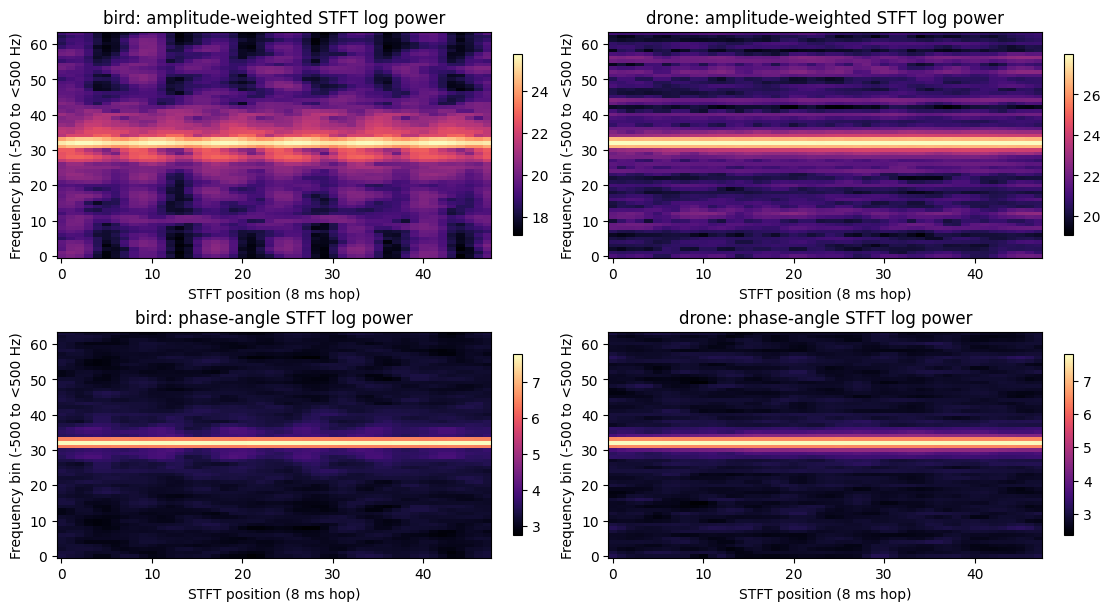

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), constrained_layout=True)
for column, class_name in enumerate(["bird", "drone"]):
    example = X[np.flatnonzero(y_name == class_name)[0]]
    for channel in range(2):
        image = axes[channel, column].imshow(example[channel].T, origin="lower", aspect="auto", cmap="magma")
        channel_name = "amplitude-weighted STFT" if channel == 0 else "phase-angle STFT"
        axes[channel, column].set_title(f"{class_name}: {channel_name} log power")
        axes[channel, column].set_xlabel("STFT position (8 ms hop)")
        axes[channel, column].set_ylabel("Frequency bin (-500 to <500 Hz)")
        fig.colorbar(image, ax=axes[channel, column], shrink=0.8)
plt.show()


### Paper-corrected phase spectrogram with rotor-style enhancement

Set `ROTOR_VIEW_RECORDING`, `ROTOR_VIEW_START_S`, and `ROTOR_VIEW_DURATION_S` below to inspect one archive recording without retraining. The selected 20×30 spatial region is centered on the strongest time-mean pixel in the processed angle–distance image sequence. Its center is reported as neutral spatial-axis-0/axis-1 bins because the release does not identify which serialized dimension maps to distance.

Because the archive contains processed spatial frames rather than live per-chirp range-FFT cubes, the dedicated live rotor STFT cannot be called on each 128×168 image. Instead, this cell computes the paper's phase-over-time STFT across the known 1 kHz time axis using the notebook's 64-sample Hann window and eight-sample hop, zero-pads to the rotor view's 128-point FFT, then reuses the rotor display's off-centre robust noise-floor subtraction, bounded adaptive gate, 3×3 support filter, $\pm2$-frequency-bin display notch, 0–30 dB scale, and broadband flash score.

The horizontal axis is measurement time in seconds and the vertical axis is temporal phase frequency in hertz. It is not a calibrated radial-velocity axis: the paper does not publish enough waveform/image-grid metadata to convert the released spatial phase sequence into m/s or RPM.


{'recording': 'mavik_0_rotation', 'label': 'drone', 'paper_sample_rate_hz': 1000.0, 'view_seconds': [0.0, 1.0], 'selected_spatial_axis0_bin': 74, 'selected_spatial_axis1_bin': 69, 'rotor_spectrogram_shape': (128, 118), 'noise_gate_db_percentiles': [3.0, 3.0, 3.0, 3.41], 'maximum_gate_db': 15.0, 'retained_cell_fraction': 0.04978813559322034, 'enhanced_peak_db': 10.103513717651367, 'flash_peak_db': 1.4504116773605347}


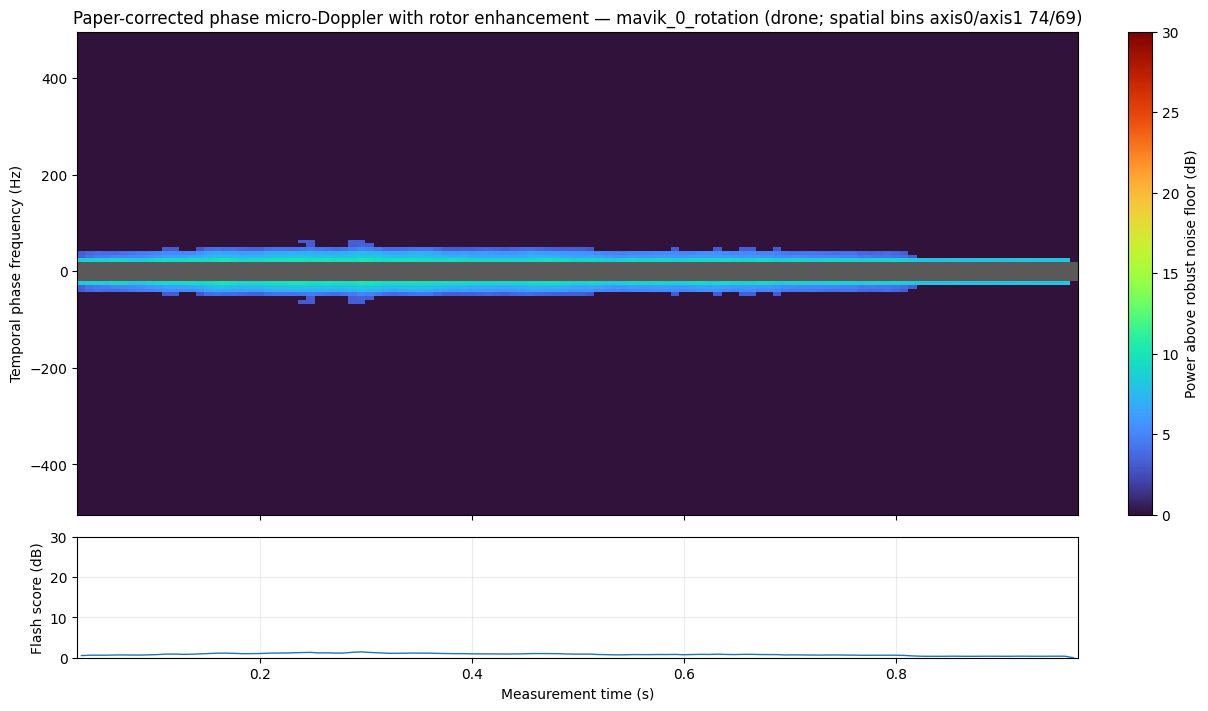

In [10]:
from rawdatacapture.dsp import (
    DEFAULT_ROTOR_NOISE_GATE_MAX_DB,
    _apply_rotor_noise_support_filter,
    _rotor_noise_floor_and_gate,
)
from rawdatacapture.livedatacapture import (
    ROTOR_MICRO_DOPPLER_DC_NOTCH_BINS,
    ROTOR_MICRO_DOPPLER_RELATIVE_DB_MAX,
)

ROTOR_VIEW_RECORDING = "mavik_0_rotation"
ROTOR_VIEW_START_S = 0.0
ROTOR_VIEW_DURATION_S = 1.0
ROTOR_VIEW_FFT_SIZE = 128

rotor_rows = [row for row in metadata if row["recording_id"] == ROTOR_VIEW_RECORDING]
if len(rotor_rows) != 1:
    available = ", ".join(sorted(row["recording_id"] for row in metadata)[:12])
    raise ValueError(
        f"Expected one recording named {ROTOR_VIEW_RECORDING!r}; found {len(rotor_rows)}. "
        f"Example available IDs: {available}"
    )
rotor_row = rotor_rows[0]
rotor_feature_indices = np.flatnonzero(recording_ids == ROTOR_VIEW_RECORDING)
if rotor_feature_indices.size == 0:
    raise ValueError(f"No cached feature windows found for {ROTOR_VIEW_RECORDING!r}")
rotor_axis0_bins = np.unique(selected_spatial_axis0_bins[rotor_feature_indices])
rotor_axis1_bins = np.unique(selected_spatial_axis1_bins[rotor_feature_indices])
if rotor_axis0_bins.size != 1 or rotor_axis1_bins.size != 1:
    raise ValueError("Expected one selected spatial centre per recording")
rotor_axis0_bin = int(rotor_axis0_bins[0])
rotor_axis1_bin = int(rotor_axis1_bins[0])

rotor_source, rotor_member = stage_recording_locally(
    DATA_SOURCE, rotor_row["name"], rotor_row["size"], rotor_row.get("drive_file_id")
)
rotor_raw = load_recording(rotor_source, rotor_member)
_, rotor_phase_power, rotor_starts, detected_axis0_bin, detected_axis1_bin = (
    archive_recording_to_spectra(rotor_raw, fft_size=ROTOR_VIEW_FFT_SIZE)
)
if (detected_axis0_bin, detected_axis1_bin) != (rotor_axis0_bin, rotor_axis1_bin):
    raise RuntimeError("Cached and freshly computed spatial target centres disagree")
rotor_times_s = (
    rotor_starts + 0.5 * (ARCHIVE_STFT_WINDOW_SAMPLES - 1)
) / ARCHIVE_SAMPLE_RATE_HZ
view_stop_s = ROTOR_VIEW_START_S + ROTOR_VIEW_DURATION_S
view_mask = (
    (rotor_times_s >= ROTOR_VIEW_START_S) & (rotor_times_s <= view_stop_s)
)
if not np.any(view_mask):
    raise ValueError(f"No STFT centres fall in {ROTOR_VIEW_START_S}:{view_stop_s} seconds")
rotor_times_s = rotor_times_s[view_mask]
rotor_raw_spectrogram_db = 10.0 * np.log10(rotor_phase_power[view_mask].T + 1e-12)
rotor_fft_center = ROTOR_VIEW_FFT_SIZE // 2
rotor_off_center = np.ones(ROTOR_VIEW_FFT_SIZE, dtype=bool)
rotor_off_center[
    rotor_fft_center - ROTOR_MICRO_DOPPLER_DC_NOTCH_BINS:
    rotor_fft_center + ROTOR_MICRO_DOPPLER_DC_NOTCH_BINS + 1
] = False
rotor_noise_floor_db, rotor_noise_gate_db = _rotor_noise_floor_and_gate(
    rotor_raw_spectrogram_db, rotor_off_center
)
rotor_relative_db = np.maximum(
    rotor_raw_spectrogram_db - rotor_noise_floor_db[None, :], 0.0
).astype(np.float32)
rotor_spectrogram_db = _apply_rotor_noise_support_filter(
    rotor_relative_db, rotor_noise_gate_db, rotor_off_center
)
rotor_excess_linear = np.maximum(
    10.0 ** (np.clip(rotor_spectrogram_db[rotor_off_center], 0.0, 30.0) / 10.0) - 1.0,
    0.0,
)
rotor_flash_scores_db = 10.0 * np.log10(1.0 + np.mean(rotor_excess_linear, axis=0))
assert np.isfinite(rotor_spectrogram_db).all() and np.isfinite(rotor_flash_scores_db).all()
rotor_retained = rotor_spectrogram_db > 0.0
rotor_diagnostics = {
    "recording": ROTOR_VIEW_RECORDING,
    "label": rotor_row["label"],
    "paper_sample_rate_hz": ARCHIVE_SAMPLE_RATE_HZ,
    "view_seconds": [ROTOR_VIEW_START_S, view_stop_s],
    "selected_spatial_axis0_bin": rotor_axis0_bin,
    "selected_spatial_axis1_bin": rotor_axis1_bin,
    "rotor_spectrogram_shape": rotor_spectrogram_db.shape,
    "noise_gate_db_percentiles": np.percentile(
        rotor_noise_gate_db, [0, 50, 95, 100]
    ).round(3).tolist(),
    "maximum_gate_db": DEFAULT_ROTOR_NOISE_GATE_MAX_DB,
    "retained_cell_fraction": float(np.mean(rotor_retained)),
    "enhanced_peak_db": float(np.max(rotor_spectrogram_db)),
    "flash_peak_db": float(np.max(rotor_flash_scores_db)),
}
print(rotor_diagnostics)
if not np.any(rotor_retained):
    raise RuntimeError(
        "Rotor-style enhancement retained no phase-STFT cells for this view; "
        "inspect the raw phase spectrogram or select another interval."
    )

# Match the live rotor display's gray, display-only DC notch.
rotor_display_db = rotor_spectrogram_db.copy()
rotor_notch_start = rotor_fft_center - ROTOR_MICRO_DOPPLER_DC_NOTCH_BINS
rotor_notch_stop = rotor_fft_center + ROTOR_MICRO_DOPPLER_DC_NOTCH_BINS + 1
rotor_display_db[rotor_notch_start:rotor_notch_stop] = np.nan
rotor_frequency_hz = sp_fft.fftshift(
    sp_fft.fftfreq(ROTOR_VIEW_FFT_SIZE, d=1.0 / ARCHIVE_SAMPLE_RATE_HZ)
)
rotor_hop_s = ARCHIVE_STFT_HOP_SAMPLES / ARCHIVE_SAMPLE_RATE_HZ
rotor_frequency_step_hz = ARCHIVE_SAMPLE_RATE_HZ / ROTOR_VIEW_FFT_SIZE

rotor_colormap = plt.get_cmap("turbo").copy()
rotor_colormap.set_bad(color="0.35")
fig, (rotor_axis, flash_axis) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True, constrained_layout=True,
    gridspec_kw={"height_ratios": [4, 1]},
)
rotor_image = rotor_axis.imshow(
    rotor_display_db,
    origin="lower",
    aspect="auto",
    cmap=rotor_colormap,
    vmin=0.0,
    vmax=ROTOR_MICRO_DOPPLER_RELATIVE_DB_MAX,
    extent=(rotor_times_s[0] - 0.5 * rotor_hop_s,
            rotor_times_s[-1] + 0.5 * rotor_hop_s,
            rotor_frequency_hz[0] - 0.5 * rotor_frequency_step_hz,
            rotor_frequency_hz[-1] + 0.5 * rotor_frequency_step_hz),
)
rotor_axis.set_title(
    f"Paper-corrected phase micro-Doppler with rotor enhancement — "
    f"{ROTOR_VIEW_RECORDING} ({rotor_row['label']}; "
    f"spatial bins axis0/axis1 {rotor_axis0_bin}/{rotor_axis1_bin})"
)
rotor_axis.set_ylabel("Temporal phase frequency (Hz)")
fig.colorbar(rotor_image, ax=rotor_axis, label="Power above robust noise floor (dB)")

flash_axis.plot(rotor_times_s, rotor_flash_scores_db, color="tab:blue", linewidth=1.0)
flash_axis.set(xlabel="Measurement time (s)", ylabel="Flash score (dB)",
               xlim=(rotor_times_s[0] - 0.5 * rotor_hop_s,
                     rotor_times_s[-1] + 0.5 * rotor_hop_s),
               ylim=(0, ROTOR_MICRO_DOPPLER_RELATIVE_DB_MAX))
flash_axis.grid(True, alpha=0.25)
plt.show()

del rotor_raw
release_recording_memory()


## 4. Grouped split, train-only normalization, and model selection

Unknown examples are excluded from the binary loss. `StratifiedGroupKFold` creates train, validation, and locked test partitions with disjoint inferred session groups. Clipping limits and channel-wise mean/standard deviation are fitted on training pixels only.

The model is L2-regularized logistic regression. This intentionally implements the simple baseline required before accepting a deeper CNN in `AI_2.md`, uses the repository's existing scikit-learn dependency, and is small enough for non-blocking CPU inference. `C` and the decision threshold are chosen on validation data only. A one-dimensional sigmoid calibrator is also fitted on validation logits; the locked test set is touched once.

In [11]:
binary = y_name != "unknown"
binary_indices = np.flatnonzero(binary)
y = (y_name[binary] == "drone").astype(np.int8)
groups = session_groups[binary]

outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
trainval_rel, test_rel = next(outer.split(np.zeros(len(y)), y, groups))
inner = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE + 1)
train_rel2, val_rel2 = next(inner.split(np.zeros(len(trainval_rel)), y[trainval_rel], groups[trainval_rel]))
train_rel, val_rel = trainval_rel[train_rel2], trainval_rel[val_rel2]
train_idx, val_idx, test_idx = binary_indices[train_rel], binary_indices[val_rel], binary_indices[test_rel]

split_indices = {"train": train_idx, "validation": val_idx, "test": test_idx}
for split, idx in split_indices.items():
    print(split, {"windows": len(idx), "recordings": len(np.unique(recording_ids[idx])),
                  "groups": len(np.unique(session_groups[idx])), "classes": dict(Counter(y_name[idx]))})
group_sets = {name: set(session_groups[idx]) for name, idx in split_indices.items()}
recording_sets = {name: set(recording_ids[idx]) for name, idx in split_indices.items()}
for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    assert group_sets[a].isdisjoint(group_sets[b])
    assert recording_sets[a].isdisjoint(recording_sets[b])

clip_low = np.percentile(X[train_idx], 0.5, axis=(0, 2, 3)).astype(np.float32)
clip_high = np.percentile(X[train_idx], 99.5, axis=(0, 2, 3)).astype(np.float32)
def clipped(X_part):
    return np.clip(X_part, clip_low[None, :, None, None], clip_high[None, :, None, None])
train_clipped = clipped(X[train_idx])
channel_mean = train_clipped.mean(axis=(0, 2, 3), dtype=np.float64).astype(np.float32)
channel_std = train_clipped.std(axis=(0, 2, 3), dtype=np.float64).astype(np.float32)
assert np.all(channel_std > 0)

def transform(X_part: np.ndarray) -> np.ndarray:
    normalized = (clipped(X_part) - channel_mean[None, :, None, None]) / channel_std[None, :, None, None]
    return normalized.reshape(len(normalized), -1).astype(np.float32, copy=False)

X_train, X_val = transform(X[train_idx]), transform(X[val_idx])
y_train = (y_name[train_idx] == "drone").astype(np.int8)
y_val = (y_name[val_idx] == "drone").astype(np.int8)
candidates = []
for C in [0.01, 0.1, 1.0]:
    candidate = LogisticRegression(C=C, solver="liblinear", penalty="l2", class_weight="balanced",
                                   max_iter=500, random_state=RANDOM_STATE)
    candidate.fit(X_train, y_train)
    val_score = average_precision_score(y_val, candidate.predict_proba(X_val)[:, 1])
    candidates.append((val_score, C, candidate))
    print(f"C={C:g}: validation PR-AUC={val_score:.4f}, iterations={candidate.n_iter_[0]}")
_, selected_C, model = max(candidates, key=lambda row: row[0])

val_logits = model.decision_function(X_val).reshape(-1, 1)
calibrator = LogisticRegression(C=1e3, solver="lbfgs", max_iter=500, random_state=RANDOM_STATE)
calibrator.fit(val_logits, y_val)
val_probability = calibrator.predict_proba(val_logits)[:, 1]
precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, val_probability)
f1_curve = 2 * precision_curve[:-1] * recall_curve[:-1] / np.maximum(precision_curve[:-1] + recall_curve[:-1], 1e-12)
threshold = float(thresholds[np.argmax(f1_curve)])
print(f"selected C={selected_C:g}; validation F1 threshold={threshold:.4f}")


train {'windows': 174, 'recordings': 58, 'groups': 29, 'classes': {np.str_('bird'): 60, np.str_('drone'): 114}}
validation {'windows': 60, 'recordings': 20, 'groups': 10, 'classes': {np.str_('bird'): 24, np.str_('drone'): 36}}
test {'windows': 63, 'recordings': 21, 'groups': 11, 'classes': {np.str_('bird'): 30, np.str_('drone'): 33}}
C=0.01: validation PR-AUC=0.9379, iterations=6
C=0.1: validation PR-AUC=0.9334, iterations=8
C=1: validation PR-AUC=0.9343, iterations=9
selected C=0.01; validation F1 threshold=0.2178


## 5. Locked-test evaluation

Metrics are reported per window and after averaging probabilities across each complete recording. Bird false-positive rate is `FP / (FP + TN)`. Expected calibration error (ECE) uses ten fixed probability bins. These archive results do not estimate operational false alarms per hour.

Window metrics:
 {
  "samples": 63,
  "threshold": 0.2177636115119384,
  "drone_recall": 0.9696969696969697,
  "bird_false_positive_rate": 0.13333333333333333,
  "precision": 0.8888888888888888,
  "f1": 0.927536231884058,
  "pr_auc_average_precision": 0.9727236787752476,
  "roc_auc": 0.9686868686868687,
  "brier_score": 0.12226214208637778,
  "ece_10_bins": 0.1817301645797896,
  "confusion_matrix_tn_fp_fn_tp": [
    26,
    4,
    1,
    32
  ]
}
Recording metrics:
 {
  "samples": 21,
  "threshold": 0.2177636115119384,
  "drone_recall": 1.0,
  "bird_false_positive_rate": 0.1,
  "precision": 0.9166666666666666,
  "f1": 0.9565217391304348,
  "pr_auc_average_precision": 0.9750688705234161,
  "roc_auc": 0.9727272727272728,
  "brier_score": 0.1218182644300545,
  "ece_10_bins": 0.19757726919781388,
  "confusion_matrix_tn_fp_fn_tp": [
    9,
    1,
    0,
    11
  ]
}


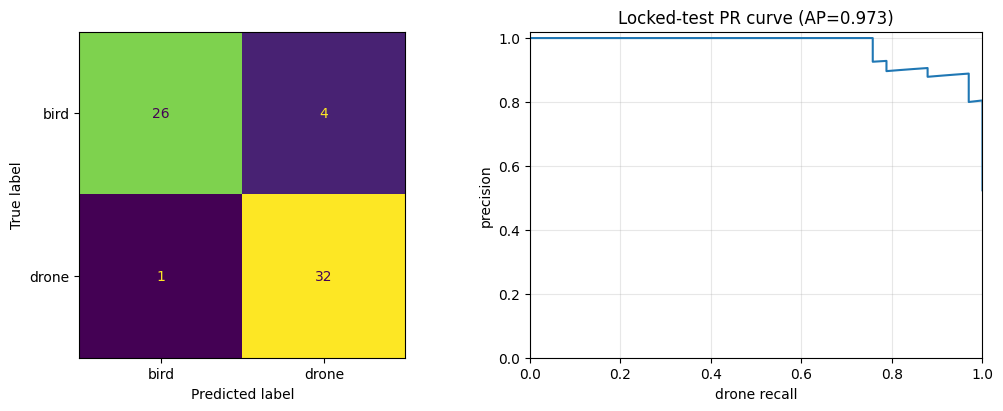

Unknown pole probe (not a general negative metric): {'windows': 3, 'mean_p_drone': 0.05847864186271287, 'max_p_drone': 0.06099269098201162, 'fraction_above_threshold': 0.0}


In [12]:
def calibrated_probability(X_flat: np.ndarray) -> np.ndarray:
    return calibrator.predict_proba(model.decision_function(X_flat).reshape(-1, 1))[:, 1]

def expected_calibration_error(y_true, probability, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    bucket = np.minimum(np.digitize(probability, edges[1:-1]), bins - 1)
    ece = 0.0
    for index in range(bins):
        mask = bucket == index
        if mask.any():
            ece += mask.mean() * abs(y_true[mask].mean() - probability[mask].mean())
    return float(ece)

def metric_summary(y_true, probability, selected_threshold):
    predicted = (probability >= selected_threshold).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    return {
        "samples": int(len(y_true)), "threshold": float(selected_threshold),
        "drone_recall": float(recall_score(y_true, predicted)),
        "bird_false_positive_rate": float(fp / max(fp + tn, 1)),
        "precision": float(precision_score(y_true, predicted, zero_division=0)),
        "f1": float(f1_score(y_true, predicted)),
        "pr_auc_average_precision": float(average_precision_score(y_true, probability)),
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "brier_score": float(brier_score_loss(y_true, probability)),
        "ece_10_bins": expected_calibration_error(y_true, probability),
        "confusion_matrix_tn_fp_fn_tp": [int(tn), int(fp), int(fn), int(tp)],
    }

X_test = transform(X[test_idx])
y_test = (y_name[test_idx] == "drone").astype(np.int8)
test_probability = calibrated_probability(X_test)
window_metrics = metric_summary(y_test, test_probability, threshold)
print("Window metrics:\n", json.dumps(window_metrics, indent=2))

record_rows = []
for recording in np.unique(recording_ids[test_idx]):
    mask = recording_ids[test_idx] == recording
    record_rows.append((recording, int(y_test[mask][0]), float(test_probability[mask].mean()), int(mask.sum())))
record_y = np.array([row[1] for row in record_rows], dtype=np.int8)
record_probability = np.array([row[2] for row in record_rows], dtype=np.float64)
record_metrics = metric_summary(record_y, record_probability, threshold)
print("Recording metrics:\n", json.dumps(record_metrics, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(y_test, test_probability >= threshold, display_labels=["bird", "drone"], ax=axes[0], colorbar=False)
p, r, _ = precision_recall_curve(y_test, test_probability)
axes[1].plot(r, p)
axes[1].set(xlabel="drone recall", ylabel="precision", title=f"Locked-test PR curve (AP={window_metrics['pr_auc_average_precision']:.3f})", xlim=(0, 1), ylim=(0, 1.02))
axes[1].grid(alpha=0.3)
plt.show()

unknown_idx = np.flatnonzero(y_name == "unknown")
unknown_summary = None
if len(unknown_idx):
    unknown_probability = calibrated_probability(transform(X[unknown_idx]))
    unknown_summary = {"windows": len(unknown_idx), "mean_p_drone": float(unknown_probability.mean()),
                       "max_p_drone": float(unknown_probability.max()),
                       "fraction_above_threshold": float((unknown_probability >= threshold).mean())}
    print("Unknown pole probe (not a general negative metric):", unknown_summary)


## 6. Archive/live incompatibility check

The earlier notebook treated the archive's 128×168 spatial image as chirp×ADC data and used a shape-only live adapter. The paper shows that interpretation is invalid. Archive examples are derived from processed 8×8 FDM-MIMO angle–distance image sequences sampled at 1 kHz; live data are raw 3-TX/4-RX TDM chirp cubes captured at about 30 frames/s.

There is no defensible direct adapter or compatible live profile hash. Live deployment now remains disabled until the IWR6843 pipeline creates an equivalent calibrated complex spatial-image sequence and temporal feature, or a new model is trained on native IWR6843 data.

In [13]:
archive_live_compatibility = {
    "compatible": False,
    "archive_input": archive_radar_contract["released_data_product"],
    "archive_rate_hz": ARCHIVE_SAMPLE_RATE_HZ,
    "live_input": "raw [chirp, RX, ADC] IWR6843 cube",
    "live_frame_rate_hz": 1000.0 / frame_period_ms,
    "compatible_profile_sha256": None,
    "reason": (
        "sensor multiplexing, antenna layout, processing stage, spatial grid, "
        "and temporal sampling differ"
    ),
}
assert archive_live_compatibility["compatible"] is False
assert archive_live_compatibility["compatible_profile_sha256"] is None
print(json.dumps(archive_live_compatibility, indent=2))


{
  "compatible": false,
  "archive_input": "processed complex 2D horizontal-angle/distance image sequence",
  "archive_rate_hz": 1000.0,
  "live_input": "raw [chirp, RX, ADC] IWR6843 cube",
  "live_frame_rate_hz": 30.003000300030006,
  "compatible_profile_sha256": null,
  "reason": "sensor multiplexing, antenna layout, processing stage, spatial grid, and temporal sampling differ"
}


## 7. Export

The bundle contains the fitted classifier, probability calibrator, validation threshold, train-only preprocessing parameters, feature schema, fingerprints, and explicit deployment status. It is a candidate for replay experiments—not permission to enable operational live decisions.

In [14]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
model_path = ARTIFACT_DIR / "drone_bird_archive_logistic_v5.joblib"
model_card_path = ARTIFACT_DIR / "drone_bird_archive_logistic_v5.model_card.json"
bundle = {
    "model": model, "calibrator": calibrator, "threshold": threshold,
    "clip_low": clip_low, "clip_high": clip_high,
    "channel_mean": channel_mean, "channel_std": channel_std,
    "selected_C": selected_C, "feature_version": FEATURE_VERSION,
    "paper_classifier_reproduction": False,
    "input_shape_chw": (2, 48, 64),
    "archive_manifest_sha256": archive_fingerprint,
    "archive_radar_contract": archive_radar_contract,
    "compatible_profile_sha256": None,
    "deployment_status": "archive_only_processed_image_domain_no_live_adapter",
}
joblib.dump(bundle, model_path, compress=3)
model_card = {
    "artifact": model_path.name, "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "objective": "drone versus bionic bird micro-Doppler archive baseline",
    "deployment_status": bundle["deployment_status"],
    "dataset": {"data_source_at_training": str(DATA_SOURCE), "source_kind": source_kind,
                "manifest_sha256": archive_fingerprint,
                "recording_counts": dict(Counter(row["target_model"] for row in metadata)),
                "excluded_nonpaper_3khz_recordings": [row["name"] for row in excluded_nonpaper_members],
                "session_group_source": "inferred from filenames; authoritative session metadata unavailable"},
    "feature_contract": {"version": FEATURE_VERSION, "shape": [2, 48, 64],
        "paper_classifier_reproduction": False,
        "axis_order": ["channel", "stft_time", "temporal_frequency"],
        "channels": ["amplitude_weighted_complex_stft_log1p_power",
                     "phase_angle_stft_log1p_power"],
        "spatial_roi_shape": [ARCHIVE_ROI_AXIS0_BINS, ARCHIVE_ROI_AXIS1_BINS],
        "sample_rate_hz": ARCHIVE_SAMPLE_RATE_HZ,
        "stft_window_samples": ARCHIVE_STFT_WINDOW_SAMPLES,
        "stft_hop_samples": ARCHIVE_STFT_HOP_SAMPLES,
        "feature_span_s": archive_feature_span_s,
        "normalization": "training-only channel clipping and standardization"},
    "archive_radar_contract": archive_radar_contract,
    "live_radar_contract": live_radar_contract,
    "archive_live_compatibility": archive_live_compatibility,
    "selected_C": selected_C, "threshold": threshold,
    "window_test_metrics": window_metrics, "recording_test_metrics": record_metrics,
    "unknown_pole_probe": unknown_summary,
    "limitations": [
        "No held-out IWR6843ISK-ODS labelled data were available.",
        "The negative class is bionic bird; it does not cover general non-drone clutter.",
        "The paper specifies 1 kHz timing but not released spatial-bin calibration, serialized axis order, or STFT settings.",
        "The notebook's two-channel STFT classifiers are adaptations, not reproductions of the paper's amplitude CNN and phase ConvLSTM.",
        "The 20x30 target crop is reproduced by size but re-centered from released data because published crop coordinates are unavailable.",
        "The archive is processed 8x8 FDM-MIMO image data and has no direct live-IWR6843 feature adapter.",
        "Two filename-marked 3 kHz supplementary recordings are excluded from the paper-grounded 1 kHz contract.",
        "One pole recording is only an unknown probe and cannot estimate false alarms per hour.",
    ],
    "software": {"python": platform.python_version(), "numpy": np.__version__,
                 "scipy": scipy.__version__, "scikit_learn": sklearn_version},
}
model_card_path.write_text(json.dumps(model_card, indent=2), encoding="utf-8")
print("Saved:", model_path, model_path.stat().st_size, "bytes")
print("Saved:", model_card_path)


Saved: /content/drive/MyDrive/UREX/Radar-UREx/Radar-UREx-output/artifacts/drone_bird_archive_logistic_v5.joblib 40757 bytes
Saved: /content/drive/MyDrive/UREX/Radar-UREx/Radar-UREx-output/artifacts/drone_bird_archive_logistic_v5.model_card.json


## 8. Compact depthwise-separable 2D CNN (implemented, not trained)

The following cells implement the Phase 1 CNN proposed in `AI_2.md`. They are intentionally left **unexecuted**: the current kernel does not have PyTorch installed, and training was not requested for this revision. Follow the optional CNN installation section in `rawdatacapture/User guide.md` and use a dedicated, [PyTorch-supported Python environment](https://pytorch.org/get-started/locally/) before running them.

The network consumes the corrected normalized `[batch, 2, 48, 64]` amplitude-weighted/phase-angle temporal STFT contract. Three residual depthwise-separable blocks learn local time/frequency patterns, while global average pooling avoids a large fully connected layer. The parameter-count assertion keeps the model below the one-million-parameter Phase 1 limit.

In [15]:
# Dependency check only; this cell does not train anything.
try:
    import copy
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, Dataset
    TORCH_AVAILABLE = True
except ModuleNotFoundError:
    TORCH_AVAILABLE = False
    print("PyTorch is not installed. Follow the optional CNN installation steps in rawdatacapture/User guide.md.")


In [16]:
CNN_CONFIG = {
    "input_channels": 2,
    "stem_channels": 16,
    "block_channels": [32, 64, 96],
    "block_strides": [(1, 2), (2, 2), (2, 2)],
    "dropout": 0.25,
}

if TORCH_AVAILABLE:
    class DepthwiseSeparableResidual(nn.Module):
        """Residual depthwise 3x3 convolution followed by pointwise 1x1 mixing."""

        def __init__(self, in_channels: int, out_channels: int, stride=(1, 1)):
            super().__init__()
            self.main = nn.Sequential(
                nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=stride,
                          padding=1, groups=in_channels, bias=False),
                nn.BatchNorm2d(in_channels),
                nn.SiLU(inplace=True),
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
            )
            self.skip = (
                nn.Identity()
                if in_channels == out_channels and tuple(stride) == (1, 1)
                else nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                    nn.BatchNorm2d(out_channels),
                )
            )
            self.activation = nn.SiLU(inplace=True)

        def forward(self, inputs):
            return self.activation(self.main(inputs) + self.skip(inputs))

    class MicroDopplerCNN(nn.Module):
        """Compact binary classifier returning one uncalibrated drone logit."""

        def __init__(self, config=CNN_CONFIG):
            super().__init__()
            stem = int(config["stem_channels"])
            channels = [stem, *map(int, config["block_channels"])]
            self.stem = nn.Sequential(
                nn.Conv2d(int(config["input_channels"]), stem, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(stem),
                nn.SiLU(inplace=True),
            )
            self.blocks = nn.Sequential(*[
                DepthwiseSeparableResidual(channels[i], channels[i + 1], tuple(config["block_strides"][i]))
                for i in range(len(config["block_channels"]))
            ])
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.dropout = nn.Dropout(float(config["dropout"]))
            self.classifier = nn.Linear(channels[-1], 1)

        def forward(self, inputs):
            if inputs.ndim != 4 or tuple(inputs.shape[1:]) != (2, 48, 64):
                raise ValueError(f"Expected [batch, 2, 48, 64], received {tuple(inputs.shape)}")
            features = self.blocks(self.stem(inputs))
            return self.classifier(self.dropout(self.pool(features).flatten(1))).squeeze(1)

    cnn = MicroDopplerCNN()
    cnn_parameter_count = sum(parameter.numel() for parameter in cnn.parameters() if parameter.requires_grad)
    with torch.no_grad():
        shape_check = cnn(torch.zeros(2, 2, 48, 64, dtype=torch.float32))
    assert shape_check.shape == (2,)
    assert cnn_parameter_count < 1_000_000
    print(f"CNN trainable parameters: {cnn_parameter_count:,}")
else:
    print("CNN definition skipped because PyTorch is unavailable. No training was run.")


CNN trainable parameters: 19,825


### CNN input pipeline and radar-safe augmentation

The CNN reuses the exact grouped indices and **training-only** clipping/normalization parameters established above. Augmentation is limited to small standardized log-power/noise changes, zero-padded STFT-time and temporal-frequency shifts, and masked-position dropout. It deliberately excludes rotations, flips, warping, and circular shifts that would invent physically misleading radar structure. Validation and test windows are never augmented.

In [17]:
if TORCH_AVAILABLE:
    def transform_cnn(X_part: np.ndarray) -> np.ndarray:
        normalized = (clipped(X_part) - channel_mean[None, :, None, None]) / channel_std[None, :, None, None]
        result = normalized.astype(np.float32, copy=False)
        if result.ndim != 4 or result.shape[1:] != (2, 48, 64) or not np.isfinite(result).all():
            raise ValueError(f"Invalid CNN tensor: {result.shape}")
        return result

    def zero_padded_shift(tensor, amount: int, dimension: int):
        if amount == 0:
            return tensor
        shifted = torch.zeros_like(tensor)
        source = [slice(None)] * tensor.ndim
        destination = [slice(None)] * tensor.ndim
        if amount > 0:
            source[dimension] = slice(None, -amount)
            destination[dimension] = slice(amount, None)
        else:
            source[dimension] = slice(-amount, None)
            destination[dimension] = slice(None, amount)
        shifted[tuple(destination)] = tensor[tuple(source)]
        return shifted

    class RadarWindowDataset(Dataset):
        def __init__(self, windows: np.ndarray, labels: np.ndarray, augment: bool = False):
            if windows.shape[1:] != (2, 48, 64) or len(windows) != len(labels):
                raise ValueError("CNN dataset expects matching [N, 2, 48, 64] windows and labels")
            self.windows = windows
            self.labels = labels.astype(np.float32, copy=False)
            self.augment = augment

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, index):
            window = torch.from_numpy(self.windows[index].copy())
            if self.augment:
                # Small log-power perturbation; the phase-angle channel remains independent.
                window[0] += torch.empty(1).uniform_(-0.08, 0.08).item()
                window += torch.randn_like(window) * 0.01
                window = zero_padded_shift(window, int(torch.randint(-2, 3, ()).item()), dimension=1)
                window = zero_padded_shift(window, int(torch.randint(-2, 3, ()).item()), dimension=2)
                if torch.rand(()) < 0.25:
                    dropped = torch.rand(window.shape[1]) < 0.05
                    window[:, dropped, :] = 0.0  # zero is padding after standardization
            return window, torch.tensor(self.labels[index], dtype=torch.float32)

    cnn_train_windows = transform_cnn(X[train_idx])
    cnn_val_windows = transform_cnn(X[val_idx])
    cnn_test_windows = transform_cnn(X[test_idx])
    cnn_train_labels = (y_name[train_idx] == "drone").astype(np.float32)
    cnn_val_labels = (y_name[val_idx] == "drone").astype(np.float32)
    cnn_test_labels = (y_name[test_idx] == "drone").astype(np.float32)
    print("CNN datasets prepared; training has not been run.",
          cnn_train_windows.shape, cnn_val_windows.shape, cnn_test_windows.shape)


CNN datasets prepared; training has not been run. (174, 2, 48, 64) (60, 2, 48, 64) (63, 2, 48, 64)


### Training loop — run manually when ready

This cell trains with weighted binary cross-entropy, AdamW, gradient clipping, and validation PR-AUC early stopping. It restores the best validation checkpoint before any test-set evaluation. It does not combine train and validation after selection, because the validation logits are subsequently used for probability calibration and threshold selection.

In [18]:
# INTENTIONALLY NOT EXECUTED IN THIS REVISION. Run this cell to train the CNN.
if not TORCH_AVAILABLE:
    raise RuntimeError("PyTorch is required. Follow the optional CNN installation steps in rawdatacapture/User guide.md.")

torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loader_generator = torch.Generator().manual_seed(RANDOM_STATE)
train_loader = DataLoader(RadarWindowDataset(cnn_train_windows, cnn_train_labels, augment=True),
                          batch_size=32, shuffle=True, num_workers=0, generator=loader_generator)
val_loader = DataLoader(RadarWindowDataset(cnn_val_windows, cnn_val_labels),
                        batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(RadarWindowDataset(cnn_test_windows, cnn_test_labels),
                         batch_size=64, shuffle=False, num_workers=0)

cnn = MicroDopplerCNN().to(device)
negative_count = float((cnn_train_labels == 0).sum())
positive_count = float((cnn_train_labels == 1).sum())
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([negative_count / positive_count], device=device))
optimizer = torch.optim.AdamW(cnn.parameters(), lr=1e-3, weight_decay=1e-4)

def cnn_logits(data_loader):
    cnn.eval()
    logits, labels = [], []
    with torch.inference_mode():
        for windows, targets in data_loader:
            logits.append(cnn(windows.to(device)).cpu().numpy())
            labels.append(targets.numpy())
    return np.concatenate(logits), np.concatenate(labels).astype(np.int8)

best_state, best_val_pr_auc, epochs_without_improvement = None, -np.inf, 0
cnn_history = []
for epoch in range(1, 101):
    cnn.train()
    running_loss = 0.0
    for windows, targets in train_loader:
        windows, targets = windows.to(device), targets.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(cnn(windows), targets)
        loss.backward()
        nn.utils.clip_grad_norm_(cnn.parameters(), max_norm=5.0)
        optimizer.step()
        running_loss += float(loss.detach()) * len(targets)
    val_logits_cnn, val_y_cnn = cnn_logits(val_loader)
    val_pr_auc = average_precision_score(val_y_cnn, val_logits_cnn)
    epoch_loss = running_loss / len(cnn_train_labels)
    cnn_history.append({"epoch": epoch, "train_loss": epoch_loss, "val_pr_auc": val_pr_auc})
    if val_pr_auc > best_val_pr_auc + 1e-4:
        best_val_pr_auc = val_pr_auc
        best_state = copy.deepcopy(cnn.state_dict())
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    print(f"epoch={epoch:03d} loss={epoch_loss:.4f} val_PR-AUC={val_pr_auc:.4f}")
    if epochs_without_improvement >= 12:
        print(f"Early stopping; restoring epoch {best_epoch}.")
        break
assert best_state is not None
cnn.load_state_dict(best_state)
cnn.eval()


epoch=001 loss=0.4280 val_PR-AUC=0.9702
epoch=002 loss=0.2805 val_PR-AUC=0.9485
epoch=003 loss=0.1908 val_PR-AUC=0.8358
epoch=004 loss=0.1407 val_PR-AUC=0.8052
epoch=005 loss=0.1427 val_PR-AUC=0.8112
epoch=006 loss=0.1261 val_PR-AUC=0.8112
epoch=007 loss=0.1168 val_PR-AUC=0.8151
epoch=008 loss=0.1070 val_PR-AUC=0.8479
epoch=009 loss=0.0989 val_PR-AUC=0.8369
epoch=010 loss=0.1279 val_PR-AUC=0.8870
epoch=011 loss=0.0810 val_PR-AUC=0.9040
epoch=012 loss=0.0811 val_PR-AUC=0.9396
epoch=013 loss=0.0950 val_PR-AUC=0.9129
Early stopping; restoring epoch 1.


MicroDopplerCNN(
  (stem): Sequential(
    (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): DepthwiseSeparableResidual(
      (main): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 2), padding=(1, 1), groups=16, bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
        (3): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (skip): Sequential(
        (0): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (activation): SiLU(inplace=True)
    )
    (1): Depthwis

### CNN calibration, locked-test evaluation, and export

Run this only after the training cell. A sigmoid calibrator and F1 threshold are fitted from validation logits; the locked test remains untouched until final evaluation. The export separates the architecture/state dictionary from scikit-learn calibration data and records that IWR6843 transfer remains unvalidated.

In [19]:
# INTENTIONALLY NOT EXECUTED IN THIS REVISION. Requires a trained `cnn`.
val_logits_cnn, val_y_cnn = cnn_logits(val_loader)
cnn_calibrator = LogisticRegression(C=1e3, solver="lbfgs", max_iter=500, random_state=RANDOM_STATE)
cnn_calibrator.fit(val_logits_cnn.reshape(-1, 1), val_y_cnn)
cnn_val_probability = cnn_calibrator.predict_proba(val_logits_cnn.reshape(-1, 1))[:, 1]
cnn_precision, cnn_recall, cnn_thresholds = precision_recall_curve(val_y_cnn, cnn_val_probability)
cnn_f1 = 2 * cnn_precision[:-1] * cnn_recall[:-1] / np.maximum(cnn_precision[:-1] + cnn_recall[:-1], 1e-12)
cnn_threshold = float(cnn_thresholds[np.argmax(cnn_f1)])

test_logits_cnn, test_y_cnn = cnn_logits(test_loader)
cnn_test_probability = cnn_calibrator.predict_proba(test_logits_cnn.reshape(-1, 1))[:, 1]
cnn_window_metrics = metric_summary(test_y_cnn, cnn_test_probability, cnn_threshold)
print("CNN locked-test window metrics:\n", json.dumps(cnn_window_metrics, indent=2))
print("Logistic baseline window metrics:\n", json.dumps(window_metrics, indent=2))

cnn_record_rows = []
for recording in np.unique(recording_ids[test_idx]):
    mask = recording_ids[test_idx] == recording
    cnn_record_rows.append((recording, int(test_y_cnn[mask][0]), float(cnn_test_probability[mask].mean())))
cnn_record_y = np.array([row[1] for row in cnn_record_rows], dtype=np.int8)
cnn_record_probability = np.array([row[2] for row in cnn_record_rows], dtype=np.float64)
cnn_record_metrics = metric_summary(cnn_record_y, cnn_record_probability, cnn_threshold)

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
cnn_state_path = ARTIFACT_DIR / "drone_bird_cnn_state_v5.pt"
cnn_calibration_path = ARTIFACT_DIR / "drone_bird_cnn_calibration_v5.joblib"
cnn_card_path = ARTIFACT_DIR / "drone_bird_cnn_v5.model_card.json"
torch.save({"state_dict": {k: v.detach().cpu() for k, v in cnn.state_dict().items()},
            "architecture": "MicroDopplerCNN", "cnn_config": CNN_CONFIG,
            "input_shape_chw": (2, 48, 64), "feature_version": FEATURE_VERSION}, cnn_state_path)
joblib.dump({"calibrator": cnn_calibrator, "threshold": cnn_threshold,
             "clip_low": clip_low, "clip_high": clip_high,
             "channel_mean": channel_mean, "channel_std": channel_std,
             "archive_manifest_sha256": archive_fingerprint,
             "archive_radar_contract": archive_radar_contract,
             "compatible_profile_sha256": None}, cnn_calibration_path, compress=3)
cnn_card = {"architecture": "compact depthwise-separable residual 2D CNN",
            "parameters": cnn_parameter_count, "best_epoch": best_epoch,
            "validation_pr_auc": best_val_pr_auc, "threshold": cnn_threshold,
            "window_test_metrics": cnn_window_metrics, "recording_test_metrics": cnn_record_metrics,
            "feature_version": FEATURE_VERSION, "input_shape_chw": [2, 48, 64],
            "paper_classifier_reproduction": False,
            "archive_manifest_sha256": archive_fingerprint,
            "archive_radar_contract": archive_radar_contract,
            "compatible_profile_sha256": None,
            "deployment_status": "archive_only_processed_image_domain_no_live_adapter"}
cnn_card_path.write_text(json.dumps(cnn_card, indent=2), encoding="utf-8")
print("Saved CNN artifacts:", cnn_state_path, cnn_calibration_path, cnn_card_path)


CNN locked-test window metrics:
 {
  "samples": 63,
  "threshold": 0.5418898264732792,
  "drone_recall": 0.5454545454545454,
  "bird_false_positive_rate": 0.3,
  "precision": 0.6666666666666666,
  "f1": 0.6,
  "pr_auc_average_precision": 0.8209616504442008,
  "roc_auc": 0.7818181818181819,
  "brier_score": 0.18343149543494477,
  "ece_10_bins": 0.16871886727548518,
  "confusion_matrix_tn_fp_fn_tp": [
    21,
    9,
    15,
    18
  ]
}
Logistic baseline window metrics:
 {
  "samples": 63,
  "threshold": 0.2177636115119384,
  "drone_recall": 0.9696969696969697,
  "bird_false_positive_rate": 0.13333333333333333,
  "precision": 0.8888888888888888,
  "f1": 0.927536231884058,
  "pr_auc_average_precision": 0.9727236787752476,
  "roc_auc": 0.9686868686868687,
  "brier_score": 0.12226214208637778,
  "ece_10_bins": 0.1817301645797896,
  "confusion_matrix_tn_fp_fn_tp": [
    26,
    4,
    1,
    32
  ]
}
Saved CNN artifacts: /content/drive/MyDrive/UREX/Radar-UREx/Radar-UREx-output/artifacts/dron

## Recommended next validation

1. Record labelled IWR6843 drone and real-bird sessions with persistent track IDs, frame-validity/drop masks, the profile fingerprint, range/aspect/motion metadata, and long drone-free background sessions.
2. Do not reuse the removed shape-only adapter. Either create a calibrated complex angle–distance image stream and matched temporal sampling for IWR6843, or define a new native-IWR feature and retrain using labelled IWR sessions.
3. Resolve the released array's spatial-axis mapping and validate the 20×30 crop against authoritative dataset code/metadata; the paper describes the spatial axes and crop size but does not publish the serialized array schema or crop coordinates.
4. Train the implemented compact CNN, compare it with the existing logistic baseline on the identical locked split, then export the selected candidate to ONNX, verify numerical parity, and measure inference plus end-to-end latency without blocking the UDP receiver.
5. Do not report general non-drone performance, live compatibility, or false alarms per hour until diverse real negative sessions and sensor-matched validation exist.